# DASC 512 Homework 7: Diabetes Progression Prediction
## Linear Regression Analysis with Feature Selection and Assumption Testing

**Student:** Mitchell Scott

**Date:** 19 August 2025

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score
from scipy import stats
from scipy.stats import jarque_bera
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
import warnings

warnings.filterwarnings("ignore")

# Set style for better plots
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
sns.set_palette("husl")

# Setup DATA_FOLDER path
import os
from DASC500.utilities.get_top_level_module import get_project_root_jupyter
DATA_FOLDER = os.path.join(get_project_root_jupyter(), "data", "DASC512", "Homework", "7")

Starting from: c:\Users\amber\Documents\Mitchell\school\2025\DASC500\DASC500\data\DASC512\Homework\7
Found indicator: pyproject.toml at c:\Users\amber\Documents\Mitchell\school\2025\DASC500\DASC500


In [2]:
# Load the data
df = pd.read_csv(os.path.join(DATA_FOLDER, "diabetes_students.csv"))

print("Dataset Information:")
print(f"Shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# %%
# Display first few rows and basic statistics
print("First 5 rows:")
display(df.head())

print("\nBasic statistics:")
display(df.describe())

Dataset Information:
Shape: (442, 12)

Column names: ['PatientID', 'AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Y']

Data types:
PatientID      int64
AGE            int64
SEX           object
BMI          float64
BP           float64
S1             int64
S2           float64
S3           float64
S4           float64
S5           float64
S6             int64
Y            float64
dtype: object

Missing values:
PatientID     0
AGE           0
SEX           0
BMI           0
BP            0
S1            0
S2            0
S3            0
S4            0
S5            0
S6            0
Y            50
dtype: int64
First 5 rows:


,PatientID,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,0,59,Male,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151.0
1,1,48,Female,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75.0
2,2,72,Male,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141.0
3,4,50,Female,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135.0
4,5,23,Female,22.6,89.0,139,64.8,61.0,2.0,4.1897,68,97.0



Basic statistics:


,PatientID,AGE,BMI,BP,S1,S2,S3,S4,S5,S6,Y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,392.000000
mean,220.500000,48.518100,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,151.301020
std,127.738666,13.109028,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.391628
min,0.000000,19.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,110.250000,38.250000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,85.000000
50%,220.500000,50.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,137.500000
75%,330.750000,59.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,210.500000
max,441.000000,79.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,341.000000


In [3]:
# Separate training data (with Y values) and test data (without Y values)
train_data = df.dropna(subset=["Y"]).copy()
test_data = df[df["Y"].isnull()].copy()

print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Remove PatientID from features and prepare feature matrix
feature_cols = ["AGE", "SEX", "BMI", "BP", "S1", "S2", "S3", "S4", "S5", "S6"]
X = train_data[feature_cols].copy()
y = train_data["Y"].copy()

# Convert SEX to numeric (Male=1, Female=0)
print(f"\nSEX value counts before encoding:\n{X['SEX'].value_counts()}")
X["SEX"] = (X["SEX"] == "Male").astype(int)
print(f"\nSEX value counts after encoding:\n{X['SEX'].value_counts()}")

Training data shape: (392, 12)
Test data shape: (50, 12)

SEX value counts before encoding:
SEX
Female    206
Male      186
Name: count, dtype: int64

SEX value counts after encoding:
SEX
0    206
1    186
Name: count, dtype: int64


In [4]:
# Train/validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")

print(f"\nResponse variable statistics:")
print(f"Training - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Validation - Mean: {y_val.mean():.2f}, Std: {y_val.std():.2f}")
print(f"Baseline RMSE (std of Y): {y_train.std():.2f}")

Training set size: 313 samples
Validation set size: 79 samples

Response variable statistics:
Training - Mean: 152.12, Std: 78.16
Validation - Mean: 148.04, Std: 74.67
Baseline RMSE (std of Y): 78.16


## 3. Exploratory Data Analysis


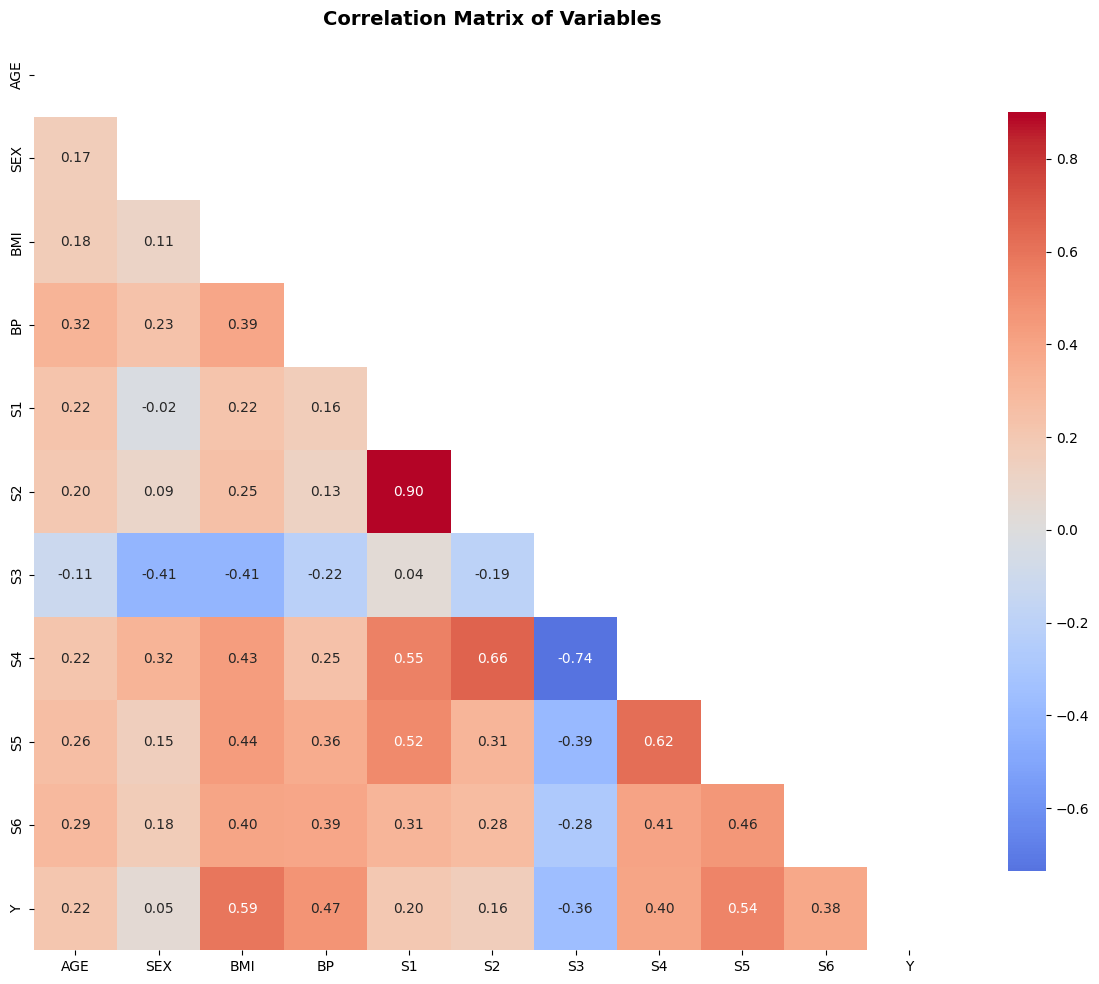

Correlations with target variable Y:
BMI    0.592699
S5     0.542082
BP     0.472726
S4     0.396290
S6     0.382039
S3    -0.360470
AGE    0.216340
S1     0.203262
S2     0.158043
SEX    0.046718
Name: Y, dtype: float64


In [5]:
# Correlation analysis
plt.figure(figsize=(12, 10))
corr_matrix = pd.concat([X_train, y_train], axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Matrix of Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Show correlations with target variable
print("Correlations with target variable Y:")
correlations = (
    pd.concat([X_train, y_train], axis=1)
    .corr()["Y"]
    .sort_values(key=abs, ascending=False)
)
print(correlations[1:])  # Exclude Y vs Y correlation

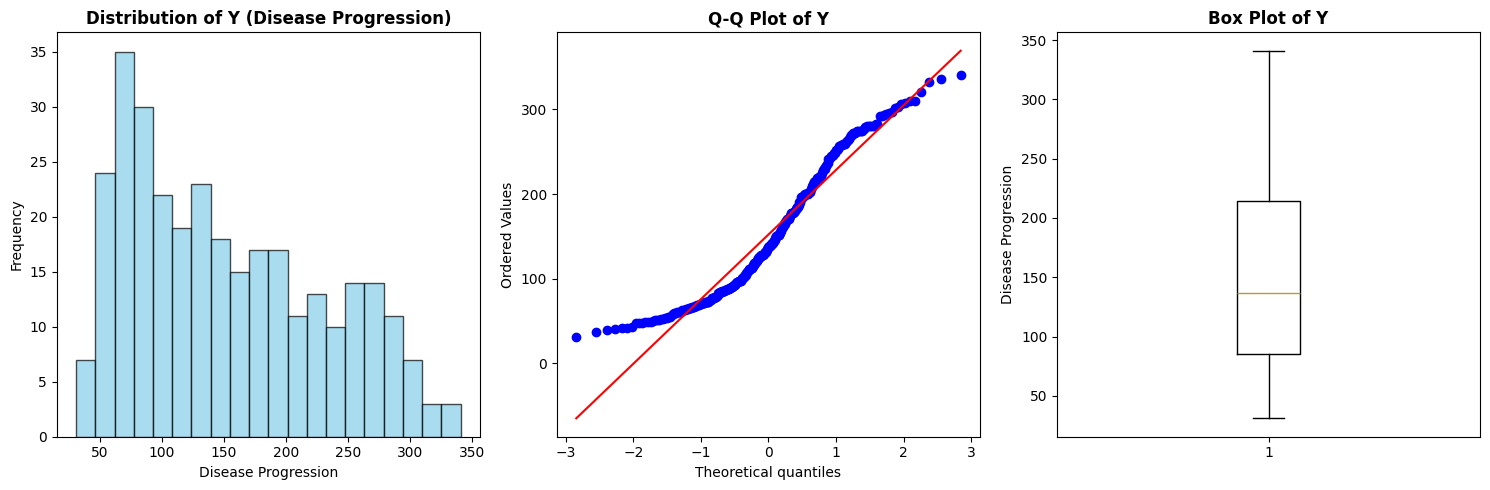

Y variable statistics:
Mean: 152.12
Median: 137.00
Std: 78.16
Min: 31.00
Max: 341.00
Skewness: 0.467
Kurtosis: -0.932


In [6]:
# Distribution analysis of response variable
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram
axes[0].hist(y_train, bins=20, alpha=0.7, color="skyblue", edgecolor="black")
axes[0].set_title("Distribution of Y (Disease Progression)", fontweight="bold")
axes[0].set_xlabel("Disease Progression")
axes[0].set_ylabel("Frequency")

# Q-Q plot
stats.probplot(y_train, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Y", fontweight="bold")

# Box plot
axes[2].boxplot(y_train)
axes[2].set_title("Box Plot of Y", fontweight="bold")
axes[2].set_ylabel("Disease Progression")

plt.tight_layout()
plt.show()

# Basic statistics
print(f"Y variable statistics:")
print(f"Mean: {y_train.mean():.2f}")
print(f"Median: {y_train.median():.2f}")
print(f"Std: {y_train.std():.2f}")
print(f"Min: {y_train.min():.2f}")
print(f"Max: {y_train.max():.2f}")
print(f"Skewness: {stats.skew(y_train):.3f}")
print(f"Kurtosis: {stats.kurtosis(y_train):.3f}")

## 4. Feature Selection

We'll use two methods:
1. Univariate F-testing (SelectKBest)
2. Recursive Feature Elimination (RFE)

In [7]:
# Method 1: Univariate feature selection with F-test
print("=" * 60)
print("FEATURE SELECTION - METHOD 1: UNIVARIATE F-TEST")
print("=" * 60)

selector_univariate = SelectKBest(score_func=f_regression, k=6)
X_train_selected_univ = selector_univariate.fit_transform(X_train, y_train)
selected_features_univariate = X_train.columns[
    selector_univariate.get_support()
].tolist()

print("F-scores for all features:")
f_scores = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "F_Score": selector_univariate.scores_,
        "P_Value": selector_univariate.pvalues_,
    }
).sort_values("F_Score", ascending=False)

print(f_scores)
print(f"\nTop 6 features selected: {selected_features_univariate}")

FEATURE SELECTION - METHOD 1: UNIVARIATE F-TEST
F-scores for all features:
  Feature     F_Score       P_Value
2     BMI  168.414257  4.503390e-31
8      S5  129.417999  2.636918e-25
3      BP   89.499822  7.861113e-19
7      S4   57.940421  3.255285e-13
9      S6   53.148841  2.574524e-12
6      S3   46.446148  4.892014e-11
0     AGE   15.270467  1.143556e-04
4      S1   13.402779  2.951366e-04
5      S2    7.967016  5.070649e-03
1     SEX    0.680274  4.101245e-01

Top 6 features selected: ['BMI', 'BP', 'S3', 'S4', 'S5', 'S6']


In [8]:
# Method 2: Recursive Feature Elimination
print("=" * 60)
print("FEATURE SELECTION - METHOD 2: RECURSIVE FEATURE ELIMINATION")
print("=" * 60)

lr_temp = LinearRegression()
rfe = RFE(estimator=lr_temp, n_features_to_select=6, step=1)
X_train_rfe = rfe.fit_transform(X_train, y_train)
selected_features_rfe = X_train.columns[rfe.support_].tolist()

print("RFE Rankings:")
rfe_rankings = pd.DataFrame(
    {"Feature": X_train.columns, "Ranking": rfe.ranking_, "Selected": rfe.support_}
).sort_values("Ranking")

print(rfe_rankings)
print(f"\nRFE selected features: {selected_features_rfe}")

FEATURE SELECTION - METHOD 2: RECURSIVE FEATURE ELIMINATION
RFE Rankings:
  Feature  Ranking  Selected
1     SEX        1      True
2     BMI        1      True
3      BP        1      True
4      S1        1      True
7      S4        1      True
8      S5        1      True
5      S2        2     False
6      S3        3     False
9      S6        4     False
0     AGE        5     False

RFE selected features: ['SEX', 'BMI', 'BP', 'S1', 'S4', 'S5']


In [9]:
# Compare methods and choose final features
print("=" * 60)
print("FEATURE SELECTION - COMPARISON AND FINAL SELECTION")
print("=" * 60)

print("Method comparison:")
print(f"Univariate F-test selected: {selected_features_univariate}")
print(f"RFE selected: {selected_features_rfe}")

# Use intersection of both methods, or fall back to univariate if intersection is too small
common_features = list(set(selected_features_univariate) & set(selected_features_rfe))
print(f"Common features: {common_features}")

if len(common_features) >= 4:
    final_features = common_features
    print(f"Using common features: {final_features}")
else:
    # If too few common features, use the top features from F-test
    final_features = selected_features_univariate
    print(f"Using top F-test features: {final_features}")

print(f"\nFINAL SELECTED FEATURES: {final_features}")

FEATURE SELECTION - COMPARISON AND FINAL SELECTION
Method comparison:
Univariate F-test selected: ['BMI', 'BP', 'S3', 'S4', 'S5', 'S6']
RFE selected: ['SEX', 'BMI', 'BP', 'S1', 'S4', 'S5']
Common features: ['S4', 'S5', 'BP', 'BMI']
Using common features: ['S4', 'S5', 'BP', 'BMI']

FINAL SELECTED FEATURES: ['S4', 'S5', 'BP', 'BMI']


## 5. Model Building and Training


In [10]:
# Build final model with selected features
print("=" * 60)
print("BUILDING FINAL MODEL")
print("=" * 60)

X_train_final = X_train[final_features]
X_val_final = X_val[final_features]

print(f"Training with {len(final_features)} features: {final_features}")
print(f"Training data shape: {X_train_final.shape}")

# Fit the linear regression model
model = LinearRegression()
model.fit(X_train_final, y_train)

# Generate predictions
y_train_pred = model.predict(X_train_final)
y_val_pred = model.predict(X_val_final)

# Display model equation
intercept = model.intercept_
coefficients = model.coef_

print("\n" + "=" * 40)
print("FINAL MODEL EQUATION:")
print("=" * 40)
equation = f"ŷ = {intercept:.3f}"
for feature, coef in zip(final_features, coefficients):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign} {coef:.3f}×{feature}"
print(equation)

# Create coefficients table
coef_df = pd.DataFrame(
    {
        "Feature": final_features,
        "Coefficient": coefficients,
        "Abs_Coefficient": np.abs(coefficients),
    }
).sort_values("Abs_Coefficient", ascending=False)

print("\nModel Coefficients (sorted by importance):")
print(coef_df)

BUILDING FINAL MODEL
Training with 4 features: ['S4', 'S5', 'BP', 'BMI']
Training data shape: (313, 4)

FINAL MODEL EQUATION:
ŷ = -344.002  -0.471×S4 + 44.616×S5 + 1.246×BP + 6.562×BMI

Model Coefficients (sorted by importance):
  Feature  Coefficient  Abs_Coefficient
1      S5    44.616492        44.616492
3     BMI     6.562082         6.562082
2      BP     1.246262         1.246262
0      S4    -0.471115         0.471115


## 6. Model Performance Evaluation

MODEL PERFORMANCE METRICS
               Metric   Training  Validation
0                RMSE  55.836002   55.052037
1                  R²   0.488008    0.449446
2  Explained Variance   0.488008    0.449616

Baseline RMSE (std of Y): 78.159
Improvement over baseline: 29.6%


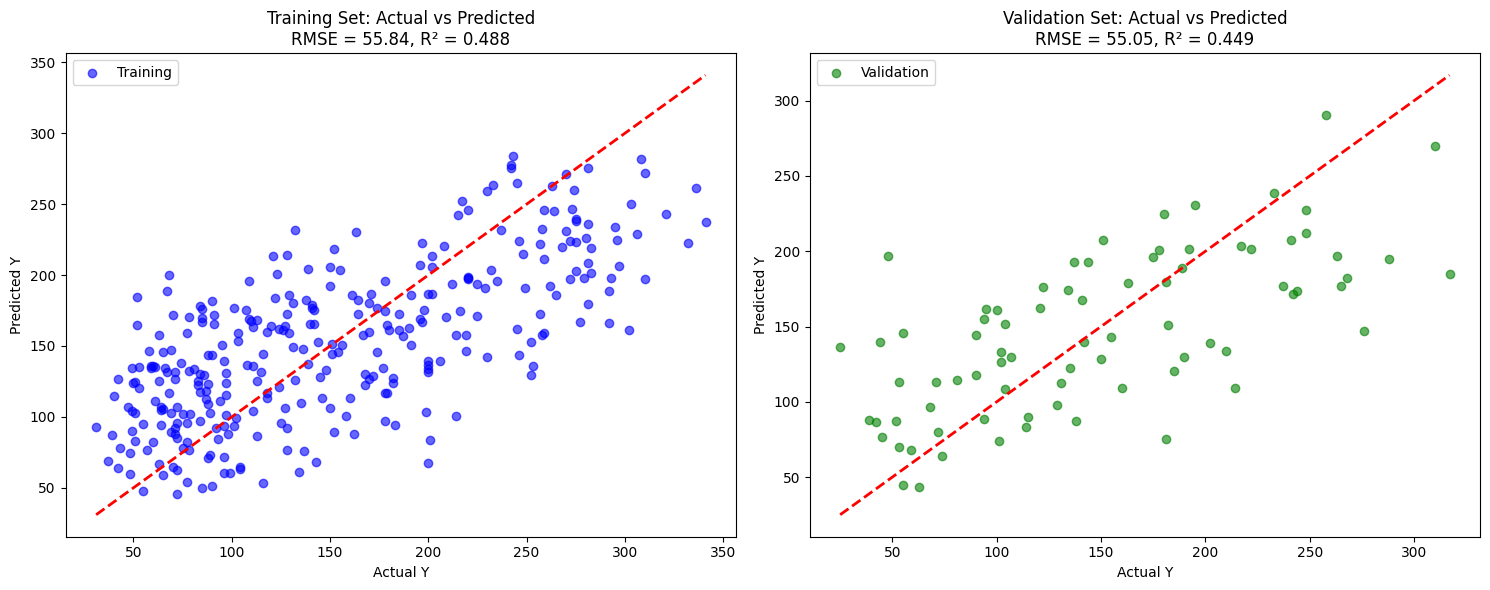

In [11]:
# Calculate performance metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
train_explained_var = explained_variance_score(y_train, y_train_pred)
val_explained_var = explained_variance_score(y_val, y_val_pred)

print("=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)

performance_df = pd.DataFrame(
    {
        "Metric": ["RMSE", "R²", "Explained Variance"],
        "Training": [train_rmse, train_r2, train_explained_var],
        "Validation": [val_rmse, val_r2, val_explained_var],
    }
)

print(performance_df)

print(f"\nBaseline RMSE (std of Y): {y_train.std():.3f}")
print(
    f"Improvement over baseline: {((y_train.std() - val_rmse) / y_train.std() * 100):.1f}%"
)

# Performance comparison plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted - Training
axes[0].scatter(y_train, y_train_pred, alpha=0.6, color="blue", label="Training")
axes[0].plot(
    [y_train.min(), y_train.max()], [y_train.min(), y_train.max()], "r--", lw=2
)
axes[0].set_xlabel("Actual Y")
axes[0].set_ylabel("Predicted Y")
axes[0].set_title(
    f"Training Set: Actual vs Predicted\nRMSE = {train_rmse:.2f}, R² = {train_r2:.3f}"
)
axes[0].legend()

# Actual vs Predicted - Validation
axes[1].scatter(y_val, y_val_pred, alpha=0.6, color="green", label="Validation")
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--", lw=2)
axes[1].set_xlabel("Actual Y")
axes[1].set_ylabel("Predicted Y")
axes[1].set_title(
    f"Validation Set: Actual vs Predicted\nRMSE = {val_rmse:.2f}, R² = {val_r2:.3f}"
)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Regression Assumptions Testing
We'll test all key assumptions:
1. Linearity
2. Normality of residuals
3. Homoscedasticity (constant variance)
4. Independence
5. Multicollinearity

REGRESSION ASSUMPTIONS TESTING


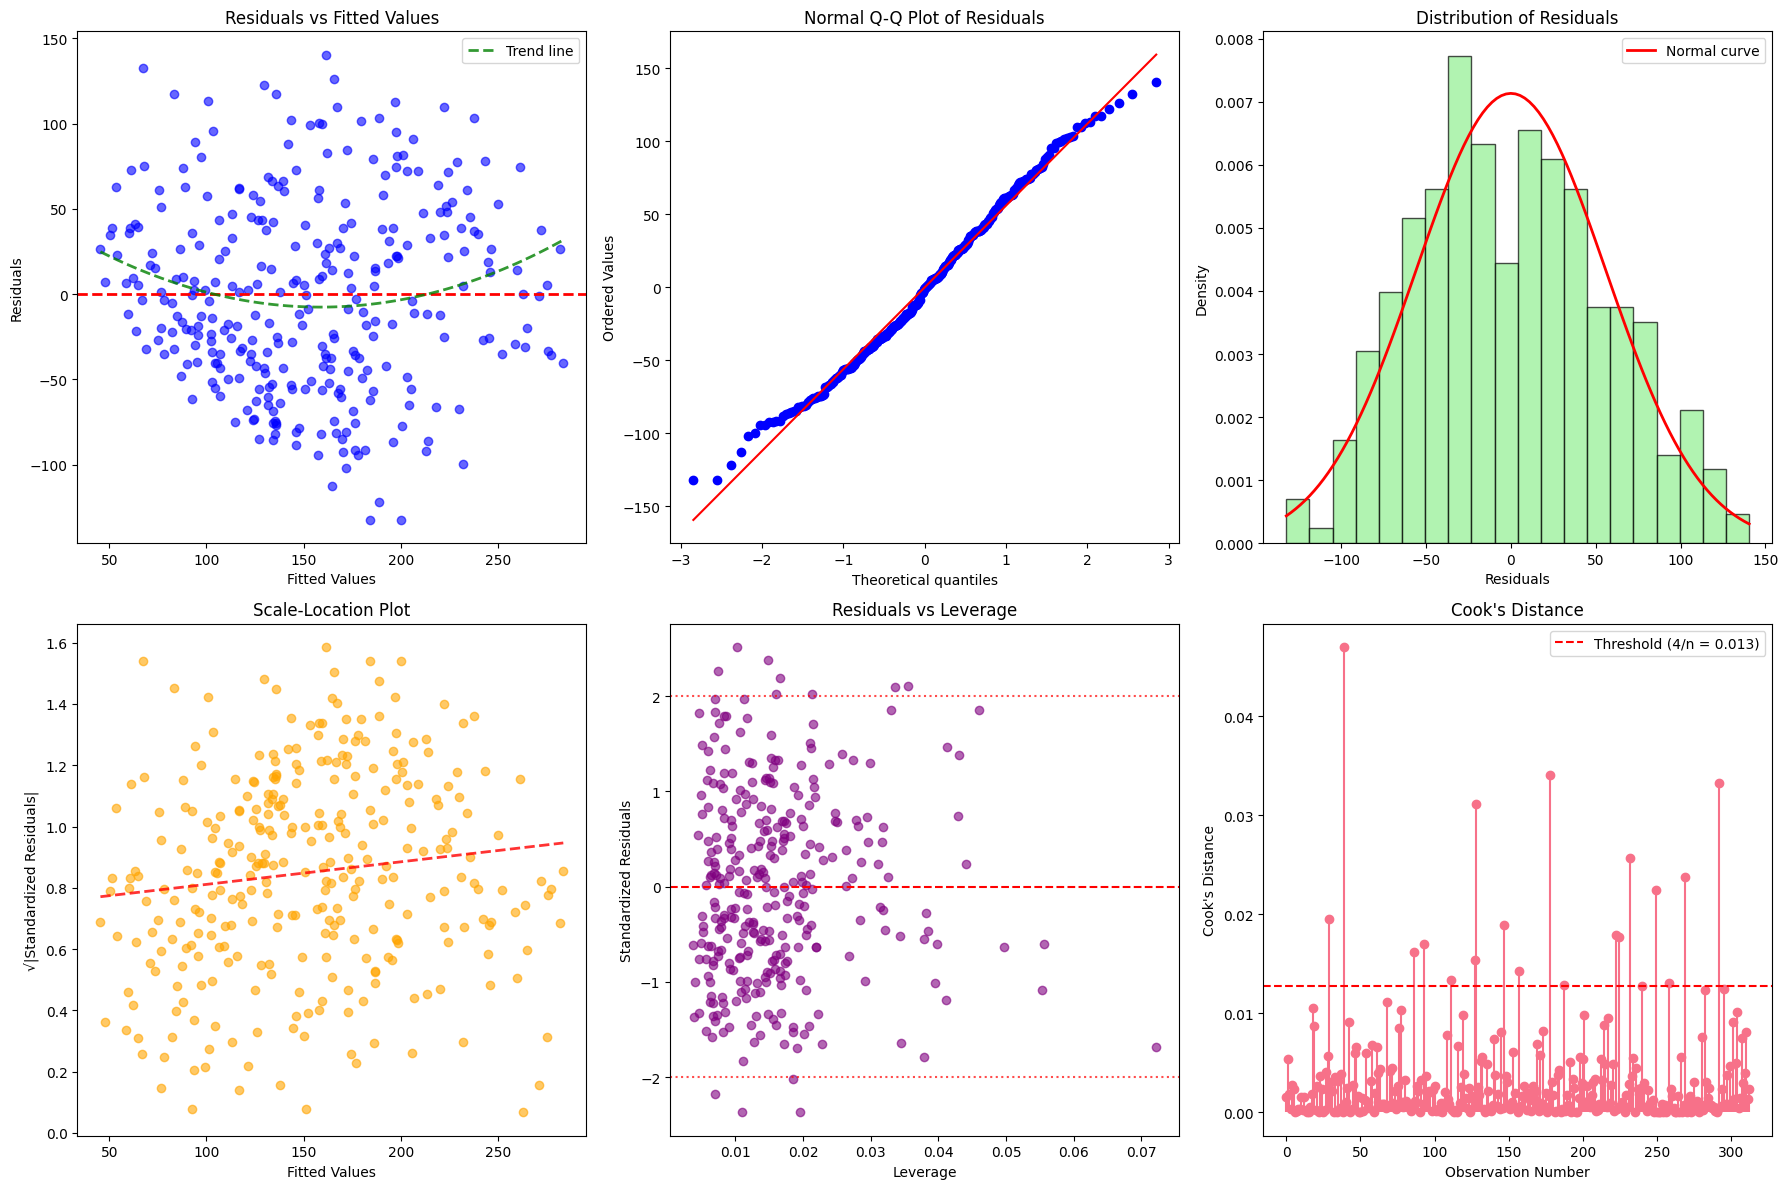

In [12]:
# Calculate residuals for assumption testing
residuals = y_train - y_train_pred
standardized_residuals = residuals / np.std(residuals)

print("=" * 60)
print("REGRESSION ASSUMPTIONS TESTING")
print("=" * 60)

# Comprehensive residual plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Residuals vs Fitted Values (Linearity and Homoscedasticity)
axes[0, 0].scatter(y_train_pred, residuals, alpha=0.6, color="blue")
axes[0, 0].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted Values")

# Add LOWESS line to check for patterns
z = np.polyfit(y_train_pred, residuals, 2)
p = np.poly1d(z)
x_smooth = np.linspace(y_train_pred.min(), y_train_pred.max(), 100)
axes[0, 0].plot(
    x_smooth, p(x_smooth), "g--", linewidth=2, alpha=0.8, label="Trend line"
)
axes[0, 0].legend()

# 2. Normal Q-Q plot of residuals
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot of Residuals")

# 3. Histogram of residuals
axes[0, 2].hist(
    residuals, bins=20, alpha=0.7, color="lightgreen", edgecolor="black", density=True
)
axes[0, 2].set_xlabel("Residuals")
axes[0, 2].set_ylabel("Density")
axes[0, 2].set_title("Distribution of Residuals")

# Add normal curve overlay
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
y_norm = stats.norm.pdf(x_norm, residuals.mean(), residuals.std())
axes[0, 2].plot(x_norm, y_norm, "r-", linewidth=2, label="Normal curve")
axes[0, 2].legend()

# 4. Scale-Location plot (Square root of standardized residuals vs fitted)
sqrt_abs_resid = np.sqrt(np.abs(standardized_residuals))
axes[1, 0].scatter(y_train_pred, sqrt_abs_resid, alpha=0.6, color="orange")
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("√|Standardized Residuals|")
axes[1, 0].set_title("Scale-Location Plot")

# Add trend line
z_scale = np.polyfit(y_train_pred, sqrt_abs_resid, 1)
p_scale = np.poly1d(z_scale)
axes[1, 0].plot(x_smooth, p_scale(x_smooth), "r--", linewidth=2, alpha=0.8)

# 5. Calculate leverages and Cook's distances using statsmodels
X_train_sm = sm.add_constant(X_train_final)
model_sm = sm.OLS(y_train, X_train_sm).fit()
influence = model_sm.get_influence()
leverages = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

# Residuals vs Leverage
axes[1, 1].scatter(leverages, standardized_residuals, alpha=0.6, color="purple")
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Standardized Residuals")
axes[1, 1].set_title("Residuals vs Leverage")
axes[1, 1].axhline(y=0, color="red", linestyle="--")
axes[1, 1].axhline(y=2, color="red", linestyle=":", alpha=0.7)
axes[1, 1].axhline(y=-2, color="red", linestyle=":", alpha=0.7)

# 6. Cook's Distance
threshold = 4 / len(y_train)
axes[1, 2].stem(range(len(cooks_d)), cooks_d, basefmt=" ")
axes[1, 2].axhline(
    y=threshold, color="red", linestyle="--", label=f"Threshold (4/n = {threshold:.3f})"
)
axes[1, 2].set_xlabel("Observation Number")
axes[1, 2].set_ylabel("Cook's Distance")
axes[1, 2].set_title("Cook's Distance")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

## 8. Statistical Tests for Assumptions

In [13]:
print("=" * 60)
print("STATISTICAL TESTS FOR ASSUMPTIONS")
print("=" * 60)

# 1. Normality Tests
print("1. NORMALITY OF RESIDUALS:")
print("-" * 30)

# Jarque-Bera test
jb_stat, jb_pvalue = jarque_bera(residuals)
print(f"Jarque-Bera Test:")
print(f"  Statistic: {jb_stat:.4f}")
print(f"  P-value: {jb_pvalue:.4f}")
print(f"  Result: {'Normal' if jb_pvalue > 0.05 else 'Non-normal'} (α = 0.05)")

# Shapiro-Wilk test
shapiro_stat, shapiro_pvalue = stats.shapiro(residuals)
print(f"\nShapiro-Wilk Test:")
print(f"  Statistic: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_pvalue:.4f}")
print(f"  Result: {'Normal' if shapiro_pvalue > 0.05 else 'Non-normal'} (α = 0.05)")

# Anderson-Darling test
ad_stat, ad_critical, ad_significance = stats.anderson(residuals, dist="norm")
print(f"\nAnderson-Darling Test:")
print(f"  Statistic: {ad_stat:.4f}")
print(f"  Critical values: {ad_critical}")
print(f"  Significance levels: {ad_significance}")

STATISTICAL TESTS FOR ASSUMPTIONS
1. NORMALITY OF RESIDUALS:
------------------------------
Jarque-Bera Test:
  Statistic: 6.0192
  P-value: 0.0493
  Result: Non-normal (α = 0.05)

Shapiro-Wilk Test:
  Statistic: 0.9897
  P-value: 0.0260
  Result: Non-normal (α = 0.05)

Anderson-Darling Test:
  Statistic: 0.8471
  Critical values: [0.569 0.648 0.777 0.907 1.078]
  Significance levels: [15.  10.   5.   2.5  1. ]


In [14]:
# 2. Homoscedasticity Tests
print("\n2. HOMOSCEDASTICITY (CONSTANT VARIANCE):")
print("-" * 40)

# Breusch-Pagan test
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(residuals, X_train_sm)
print(f"Breusch-Pagan Test:")
print(f"  LM Statistic: {bp_stat:.4f}")
print(f"  P-value: {bp_pvalue:.4f}")
print(
    f"  Result: {'Homoscedastic' if bp_pvalue > 0.05 else 'Heteroscedastic'} (α = 0.05)"
)

# White test
white_stat, white_pvalue, white_fstat, white_fpvalue = het_white(residuals, X_train_sm)
print(f"\nWhite Test:")
print(f"  LM Statistic: {white_stat:.4f}")
print(f"  P-value: {white_pvalue:.4f}")
print(
    f"  Result: {'Homoscedastic' if white_pvalue > 0.05 else 'Heteroscedastic'} (α = 0.05)"
)


2. HOMOSCEDASTICITY (CONSTANT VARIANCE):
----------------------------------------
Breusch-Pagan Test:
  LM Statistic: 4.7065
  P-value: 0.3188
  Result: Homoscedastic (α = 0.05)

White Test:
  LM Statistic: 27.5665
  P-value: 0.0162
  Result: Heteroscedastic (α = 0.05)


In [15]:
# 3. Multicollinearity Assessment
print("\n3. MULTICOLLINEARITY (VIF ANALYSIS):")
print("-" * 35)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_sm.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])
]

print(vif_data)

print("\nVIF Interpretation:")
print("- VIF = 1: No multicollinearity")
print("- 1 < VIF < 5: Moderate multicollinearity (acceptable)")
print("- 5 < VIF < 10: High multicollinearity (concerning)")
print("- VIF > 10: Very high multicollinearity (problematic)")

high_vif = vif_data[vif_data["VIF"] > 5]
if len(high_vif) > 0:
    print(f"\nFeatures with concerning VIF (>5): {high_vif['Feature'].tolist()}")
else:
    print("\nAll features have acceptable VIF values (<5)")


3. MULTICOLLINEARITY (VIF ANALYSIS):
-----------------------------------
  Feature         VIF
0   const  107.544450
1      S4    1.715515
2      S5    1.811153
3      BP    1.244325
4     BMI    1.413704

VIF Interpretation:
- VIF = 1: No multicollinearity
- 1 < VIF < 5: Moderate multicollinearity (acceptable)
- 5 < VIF < 10: High multicollinearity (concerning)
- VIF > 10: Very high multicollinearity (problematic)

Features with concerning VIF (>5): ['const']


In [16]:
# 4. Independence Test (Durbin-Watson)
print("\n4. INDEPENDENCE OF RESIDUALS:")
print("-" * 30)

dw_stat = sm.stats.durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_stat:.4f}")
print("\nInterpretation:")
print("- DW ≈ 2: No autocorrelation")
print("- DW < 1.5: Positive autocorrelation")
print("- DW > 2.5: Negative autocorrelation")

if 1.5 <= dw_stat <= 2.5:
    print("Result: No significant autocorrelation detected")
elif dw_stat < 1.5:
    print("Result: Possible positive autocorrelation")
else:
    print("Result: Possible negative autocorrelation")



4. INDEPENDENCE OF RESIDUALS:
------------------------------
Durbin-Watson Statistic: 2.0760

Interpretation:
- DW ≈ 2: No autocorrelation
- DW < 1.5: Positive autocorrelation
- DW > 2.5: Negative autocorrelation
Result: No significant autocorrelation detected


## 9. Model Summary and Interpretation

In [17]:
# Detailed model summary using statsmodels
print("=" * 60)
print("DETAILED MODEL SUMMARY")
print("=" * 60)

print(model_sm.summary())

DETAILED MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     73.39
Date:                Tue, 19 Aug 2025   Prob (F-statistic):           1.28e-43
Time:                        20:56:29   Log-Likelihood:                -1703.1
No. Observations:                 313   AIC:                             3416.
Df Residuals:                     308   BIC:                             3435.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -344.0016     32.


FEATURE IMPORTANCE AND INTERPRETATION


Feature Analysis (sorted by importance):
    Feature  Coefficient  Abs_Coefficient       P_Value  Std_Error  \
S5       S5    44.616492        44.616492  7.683387e-08   8.100962   
BMI     BMI     6.562082         6.562082  1.035325e-13   0.842402   
BP       BP     1.246262         1.246262  2.320321e-06   0.258873   
S4       S4    -0.471115         0.471115  8.825777e-01   3.186981   

     95%_CI_Lower  95%_CI_Upper  Significant  
S5      28.676262     60.556723         True  
BMI      4.904491      8.219674         True  
BP       0.736878      1.755646         True  
S4      -6.742124      5.799894        False  


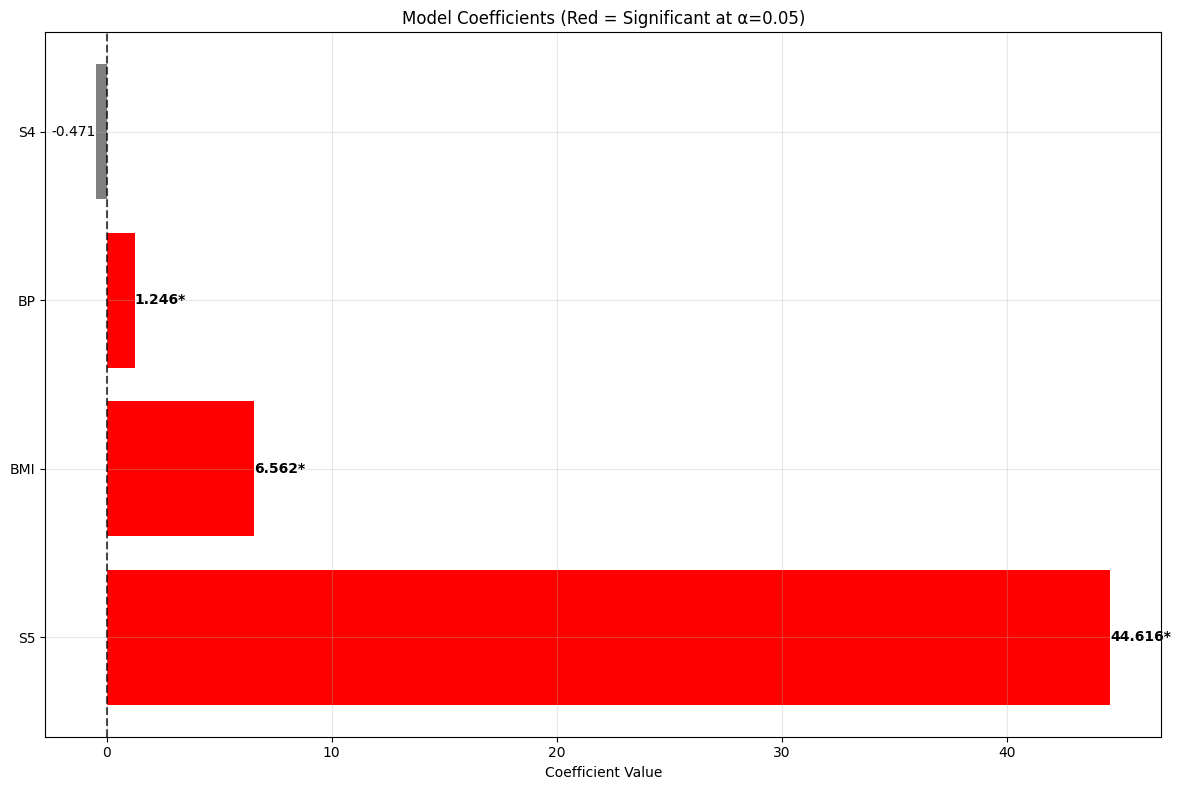

In [24]:
# Feature importance analysis
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE AND INTERPRETATION")
print("=" * 60)

# Create a comprehensive feature analysis
feature_analysis = pd.DataFrame(
    {
        "Feature": final_features,
        "Coefficient": coefficients,
        "Abs_Coefficient": np.abs(coefficients),
        "P_Value": model_sm.pvalues[1:],  # Exclude intercept
        "Std_Error": model_sm.bse[1:],  # Exclude intercept
        "95%_CI_Lower": model_sm.conf_int()[1:].iloc[:, 0],
        "95%_CI_Upper": model_sm.conf_int()[1:].iloc[:, 1],
    }
).sort_values("Abs_Coefficient", ascending=False)

feature_analysis["Significant"] = feature_analysis["P_Value"] < 0.05

print("Feature Analysis (sorted by importance):")
print(feature_analysis)

# Visualize coefficients
plt.figure(figsize=(12, 8))
colors = ["red" if p < 0.05 else "gray" for p in feature_analysis["P_Value"]]
bars = plt.barh(
    range(len(feature_analysis)), feature_analysis["Coefficient"], color=colors
)
plt.yticks(range(len(feature_analysis)), feature_analysis["Feature"])
plt.xlabel("Coefficient Value")
plt.title("Model Coefficients (Red = Significant at α=0.05)")
plt.axvline(x=0, color="black", linestyle="--", alpha=0.7)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, coef, pval) in enumerate(
    zip(bars, feature_analysis["Coefficient"], feature_analysis["P_Value"])
):
    plt.text(
        coef + (0.01 if coef > 0 else -0.01),
        i,
        f"{coef:.3f}*" if pval < 0.05 else f"{coef:.3f}",
        ha="left" if coef > 0 else "right",
        va="center",
        fontweight="bold" if pval < 0.05 else "normal",
    )

plt.tight_layout()
plt.show()

## 10. Test Set Predictions with Prediction Intervals

In [19]:
print("=" * 60)
print("GENERATING TEST SET PREDICTIONS")
print("=" * 60)

# Prepare test data
X_test = test_data[feature_cols].copy()
X_test["SEX"] = (X_test["SEX"] == "Male").astype(int)
X_test_final = X_test[final_features]

print(f"Test set shape: {X_test_final.shape}")
print(f"Test set features: {final_features}")

# Generate point predictions
test_predictions = model.predict(X_test_final)

# Calculate 90% prediction intervals
X_test_sm = sm.add_constant(X_test_final)
predictions_sm = model_sm.predict(X_test_sm)

# Standard error of prediction (includes both model uncertainty and individual prediction uncertainty)
mse = model_sm.scale  # Mean squared error
pred_se = np.sqrt(mse * (1 + np.diag(X_test_sm @ model_sm.cov_params() @ X_test_sm.T)))

# 90% prediction interval (α = 0.10, so use 95th percentile)
alpha = 0.10
t_critical = stats.t.ppf(1 - alpha / 2, df=model_sm.df_resid)
margin_of_error = t_critical * pred_se

lower_bounds = predictions_sm - margin_of_error
upper_bounds = predictions_sm + margin_of_error

# Create predictions DataFrame
predictions_df = pd.DataFrame(
    {
        "PatientID": test_data["PatientID"].astype(int),
        "Y": test_predictions,
        "Lower": lower_bounds,
        "Upper": upper_bounds,
    }
)

print("Test Set Predictions Summary:")
print(predictions_df.head(10))

print(f"\nPrediction Statistics:")
print(f"Mean prediction: {test_predictions.mean():.2f}")
print(f"Std deviation of predictions: {test_predictions.std():.2f}")
print(f"Min prediction: {test_predictions.min():.2f}")
print(f"Max prediction: {test_predictions.max():.2f}")
print(f"Mean prediction interval width: {(upper_bounds - lower_bounds).mean():.2f}")

GENERATING TEST SET PREDICTIONS
Test set shape: (50, 4)
Test set features: ['S4', 'S5', 'BP', 'BMI']
Test Set Predictions Summary:
     PatientID           Y       Lower        Upper
392          3  142.537501 -343.407781   628.482783
393         16  221.929200 -565.721226  1009.579626
394         24  153.059465 -359.109447   665.228378
395         31   65.661689 -667.586404   798.909783
396         34   64.291321 -505.884735   634.467376
397         36  212.559436 -569.314963   994.433834
398         38  265.055067 -491.403331  1021.513466
399         47   78.627949 -530.411579   687.667477
400         62   93.433333 -550.022901   736.889568
401         80  187.434328 -257.840121   632.708776

Prediction Statistics:
Mean prediction: 160.77
Std deviation of predictions: 55.16
Min prediction: 62.78
Max prediction: 266.10
Mean prediction interval width: 1214.49


In [20]:
# Save predictions to CSV
predictions_df.to_csv("predictions.csv", index=False)
print(f"✅ Predictions saved to 'predictions.csv'")

# Verify the file was created correctly
verification_df = pd.read_csv("predictions.csv")
print(f"\nVerification - predictions.csv shape: {verification_df.shape}")
print(f"Columns: {list(verification_df.columns)}")
print("\nFirst few rows from saved file:")
print(verification_df.head())

✅ Predictions saved to 'predictions.csv'

Verification - predictions.csv shape: (50, 4)
Columns: ['PatientID', 'Y', 'Lower', 'Upper']

First few rows from saved file:
   PatientID           Y       Lower        Upper
0          3  142.537501 -343.407781   628.482783
1         16  221.929200 -565.721226  1009.579626
2         24  153.059465 -359.109447   665.228378
3         31   65.661689 -667.586404   798.909783
4         34   64.291321 -505.884735   634.467376


In [21]:
print("\n" + "=" * 60)
print("FINAL MODEL EQUATION")
print("=" * 60)

print(f"ŷ = {intercept:.3f}", end="")
for feature, coef in zip(final_features, coefficients):
    sign = " + " if coef >= 0 else " - "
    print(f"{sign}{abs(coef):.3f}×{feature}", end="")
print()

print(f"\nWhere:")
print(f"• ŷ = Predicted disease progression score")
for feature in final_features:
    if feature == "SEX":
        print(f"• {feature} = Patient sex (1=Male, 0=Female)")
    elif feature == "BMI":
        print(f"• {feature} = Body Mass Index")
    elif feature == "BP":
        print(f"• {feature} = Average Blood Pressure")
    elif feature == "AGE":
        print(f"• {feature} = Patient age in years")
    elif feature.startswith("S"):
        print(f"• {feature} = Blood serum measurement {feature}")
    else:
        print(f"• {feature} = {feature}")



FINAL MODEL EQUATION
ŷ = -344.002 - 0.471×S4 + 44.616×S5 + 1.246×BP + 6.562×BMI

Where:
• ŷ = Predicted disease progression score
• S4 = Blood serum measurement S4
• S5 = Blood serum measurement S5
• BP = Average Blood Pressure
• BMI = Body Mass Index
